#Classificação - K-vizinhos mais próximos (K-nearest neighbors)


Importando a biblioteca PyPlot do Matplotlib e colocando algumas predefinições de gráficos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
plt.rc('font', **{'size':18})

Semente fixa: sem ela o `train_test_split` sorteia uma partição diferente a cada execução e nenhum número abaixo se repete.

In [2]:
SEED = 42

Carregando os dados que trabalharemos

In [3]:
# carregando os dados: arquivo local (Jupyter/VS Code) ou upload (Google Colab)
from pathlib import Path
ARQUIVO = Path('Howell1.csv')
if not ARQUIVO.exists():
    from google.colab import files
    files.upload()

In [4]:
# carregando o arquivo para o dataframe (df_completo guarda as 544 linhas originais)
df_completo = pd.read_csv(ARQUIVO, sep=';')
df = df_completo.copy()

In [5]:
df.shape

(544, 4)

In [6]:
df = df_completo.query('age>18')
df.head(5)

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


In [7]:
df.shape

(346, 4)

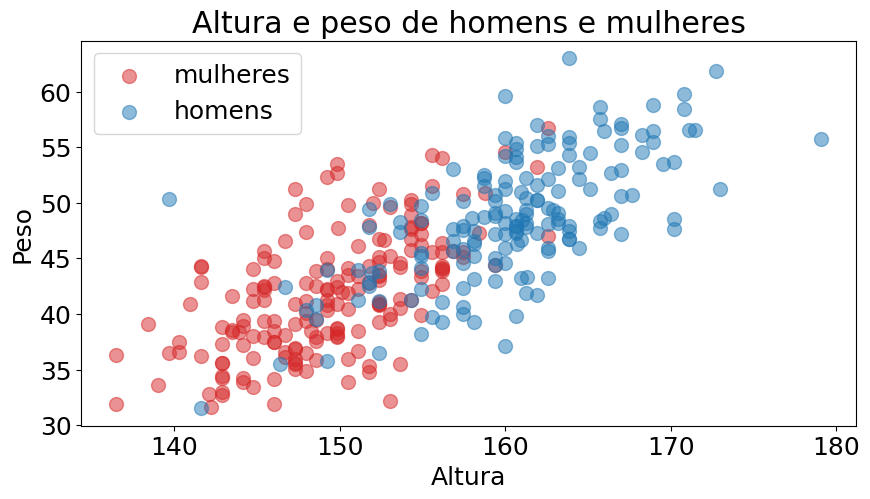

In [8]:
plt.figure(figsize=(10, 5))

plt.scatter(df.query("male==0")['height'], df.query("male==0")['weight'],
            c='tab:red', s=100, alpha=0.5, label='mulheres')
plt.scatter(df.query("male==1")['height'], df.query("male==1")['weight'],
            c='tab:blue', s=100, alpha=0.5, label='homens')

plt.xlabel('Altura')
plt.ylabel('Peso')
plt.legend()
plt.title('Altura e peso de homens e mulheres');

In [9]:
import seaborn as sns

In [10]:
df.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


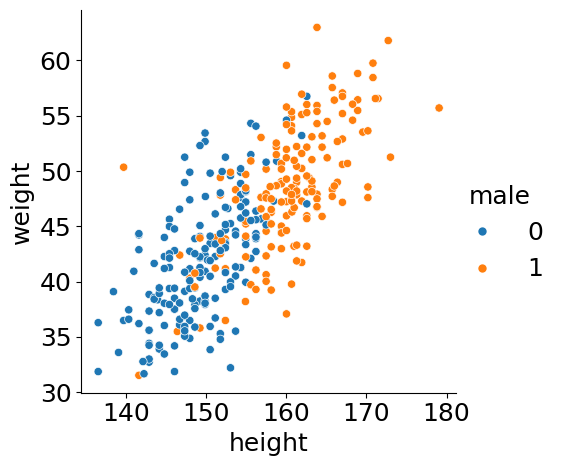

In [11]:
sns.relplot(data=df, x='height', y='weight', hue='male')

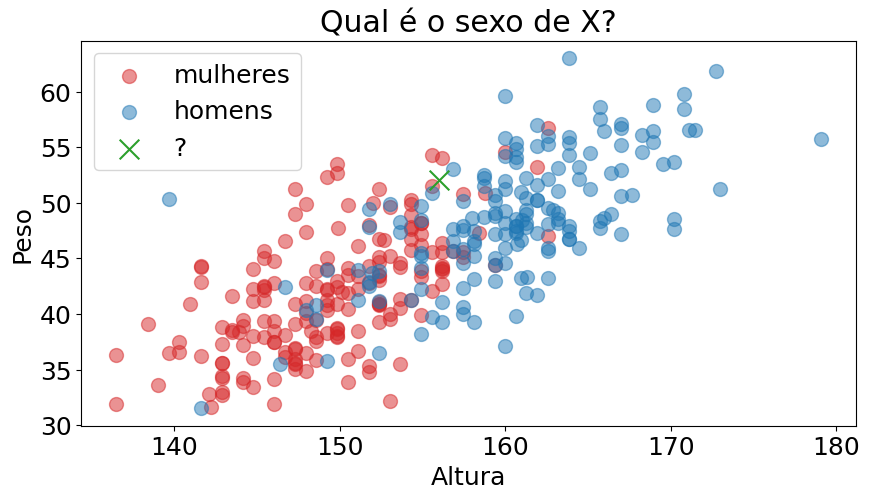

In [12]:
# ponto que queremos classificar (o mesmo usado nas predições mais abaixo)
ponto_x = (156, 52)

plt.figure(figsize=(10, 5))

plt.scatter(df.query("male==0")['height'], df.query("male==0")['weight'],
            c='tab:red', s=100, alpha=0.5, label='mulheres')
plt.scatter(df.query("male==1")['height'], df.query("male==1")['weight'],
            c='tab:blue', s=100, alpha=0.5, label='homens')

#vamos chutar um valor
plt.scatter(*ponto_x, marker='x', s=200, c='tab:green', label='?')

plt.xlabel('Altura')
plt.ylabel('Peso')
plt.legend()
plt.title('Qual é o sexo de X?');

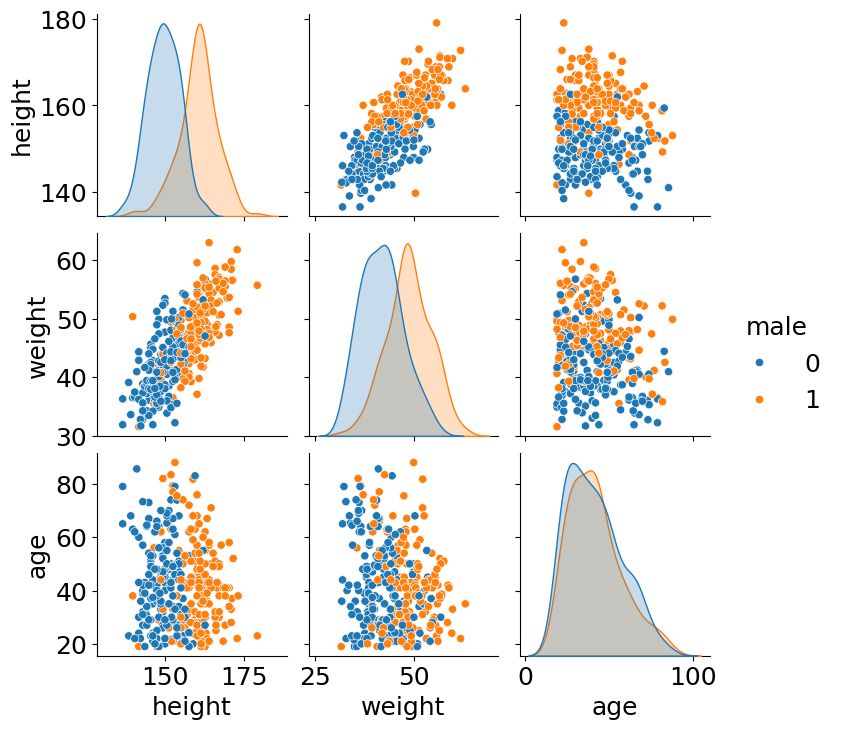

In [13]:
import seaborn as sns
sns.pairplot(df, hue='male')

In [14]:
df.std()

height     7.773564
weight     6.455220
age       15.809304
male       0.500046
dtype: float64

## Aplicando  K-vizinhos mais próximos (K-nearest neighbors)

Vamos aplicar um classificador nos dados chamado de KNN (K-Nearest Neighbours ou K-Vizinhos mais próximos). Para isso, usaremos a biblioteca *Sklearn*

In [15]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

Vamos dividir o conjunto de dados em um conjunto de treino (com 2/3 dos dados) e um conjunto de teste (com 1/3 dos dados).

In [16]:
df_treino, df_teste = train_test_split(df, test_size=0.33, shuffle=True, random_state=SEED)

Vamos dar uma espiada nos dados

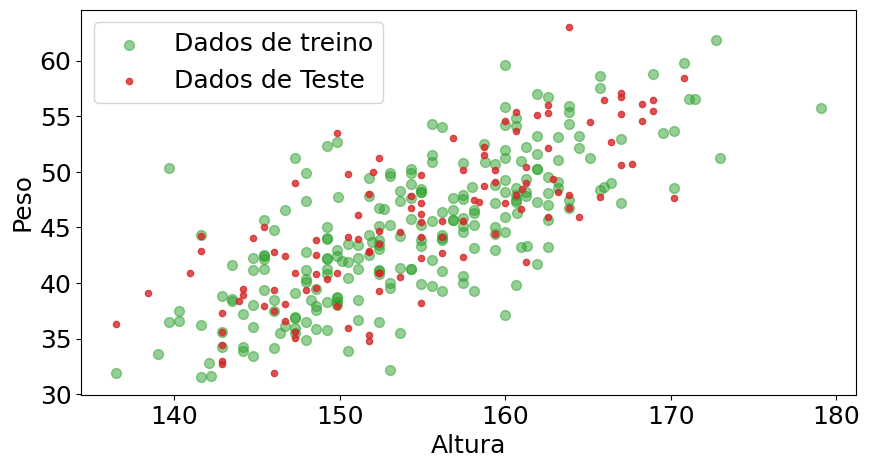

In [17]:
plt.figure(figsize=(10, 5))
plt.scatter(df_treino['height'], df_treino['weight'],
            c='tab:green', s=50, alpha=0.5, label='Dados de treino')
plt.scatter(df_teste['height'], df_teste['weight'],
            c='tab:red', s=20, alpha=0.8, label='Dados de Teste')

plt.xlabel('Altura')
plt.ylabel('Peso')
plt.legend();

## Testando para K = 1

In [18]:
X_treino, y_treino = df_treino[['height', 'weight']], df_treino['male']
X_teste, y_teste = df_teste[['height', 'weight']], df_teste['male']

In [19]:
classificador = KNeighborsClassifier(n_neighbors=1)

classificador.fit(X_treino, y_treino)
y_pred_treino = classificador.predict(X_treino)
y_pred_teste = classificador.predict(X_teste)

Olhando as acurácias

In [20]:
accuracy_score(y_treino, y_pred_treino)

1.0

In [21]:
accuracy_score(y_teste, y_pred_teste)

0.8

In [22]:
confusion_matrix(y_teste, y_pred_teste)

array([[49, 11],
       [12, 43]])

In [23]:
df['male'].value_counts()

male
0    182
1    164
Name: count, dtype: int64

##Testando para K = 2,3,4,...10

In [24]:
acu_teste = []
acu_treino = []

for k in range(1,11):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_treino, y_treino)

    y_pred = model.predict(X_teste)
    y_pred_treino = model.predict(X_treino)

    acu_teste.append(accuracy_score(y_teste, y_pred))
    acu_treino.append(accuracy_score(y_treino, y_pred_treino))

Plotando um gráfico com as acurácias

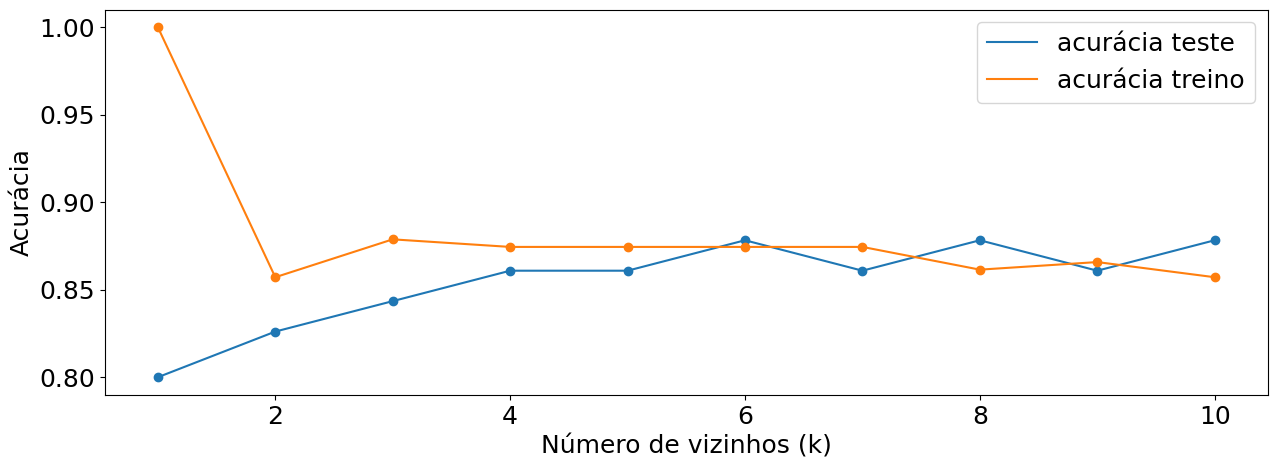

In [25]:
plt.figure(figsize=(15,5))

plt.plot(range(1,11), acu_teste, label='acurácia teste');
plt.plot(range(1,11), acu_treino, label='acurácia treino');

plt.scatter(range(1,11), acu_teste);
plt.scatter(range(1,11), acu_treino);

plt.xlabel('Número de vizinhos (k)')
plt.ylabel('Acurácia');
plt.legend();

## Aumentando ainda mais K

In [26]:
acu_teste = []
acu_treino = []
max_k = 30
for k in range(1,max_k+1):
    model = KNeighborsClassifier(n_neighbors = k)
    model.fit(X_treino, y_treino)

    y_pred = model.predict(X_teste)
    y_pred_treino = model.predict(X_treino)

    acu_teste.append(accuracy_score(y_teste, y_pred))
    acu_treino.append(accuracy_score(y_treino, y_pred_treino))

Plotando um gráfico com as acurácias

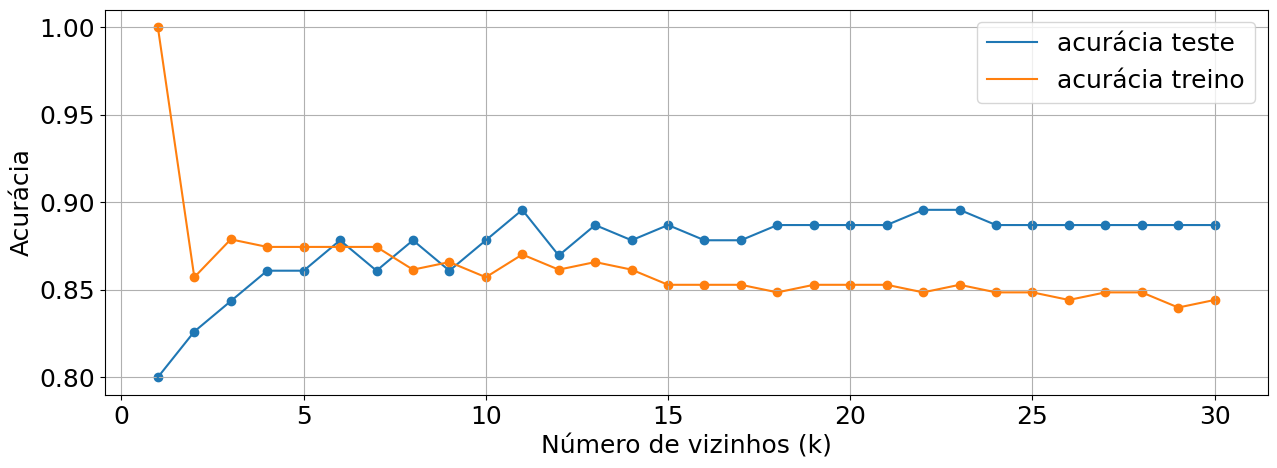

In [27]:
plt.figure(figsize=(15,5))

plt.plot(range(1,max_k+1), acu_teste, label='acurácia teste');
plt.plot(range(1,max_k+1), acu_treino, label='acurácia treino');

plt.scatter(range(1,max_k+1), acu_teste);
plt.scatter(range(1,max_k+1), acu_treino);

plt.xlabel('Número de vizinhos (k)')
plt.ylabel('Acurácia');
plt.grid()
plt.legend();

Índices dos valores máximos ao longo do eixo da acurácia do teste.

In [28]:
np.argmax(acu_teste)

np.int64(10)

Qual é o valor desse índice (máxima acurácia no teste)

In [29]:
acu_teste[np.argmax(acu_teste)]

0.8956521739130435

Encontrando o melhor K

In [30]:
k_bruto = int(np.argmax(acu_teste)) + 1   # o índice começa em 0, k começa em 1
melhor_k = KNeighborsClassifier(k_bruto)
melhor_k.fit(X_treino, y_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [31]:
dados = df_teste.copy()
dados['pred'] = melhor_k.predict(X_teste)
dados.head(10)

,height,weight,age,male,pred
150,154.3050,47.853956,34.0,0,0
218,145.4150,44.990657,37.0,0,0
424,142.8750,35.606972,42.0,0,0
286,153.6700,40.511435,73.9,0,0
495,141.6050,42.885420,43.0,0,0
227,161.0106,48.420946,31.0,1,1
164,140.9700,40.936678,85.6,0,0
142,152.4000,39.292407,49.0,0,0
346,148.5900,42.524250,35.0,0,0
497,163.8300,46.776675,21.0,1,1


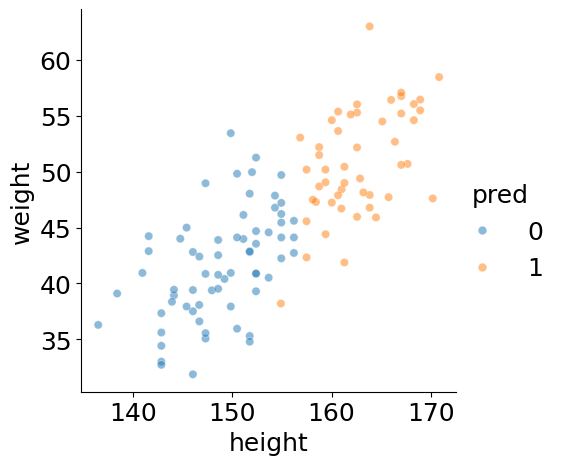

In [32]:
sns.relplot(data=dados, x='height', y='weight', hue='pred', alpha=0.5)

In [33]:
x_novo = pd.DataFrame([ponto_x], columns=['height', 'weight'])

# guardando as curvas deste experimento (acu_treino e acu_teste são reutilizadas adiante)
curvas = {'bruto': {'treino': acu_treino, 'teste': acu_teste, 'melhor_k': k_bruto,
                    'pred_x': int(melhor_k.predict(x_novo)[0])}}

melhor_k.predict(x_novo)

array([0])

## Normalização
O KNN mede distância, então a variável de maior variação pesa mais na decisão. Aqui os desvios-padrão de altura e peso já são parecidos, então o efeito esperado é pequeno — a comparação abaixo usa a **mesma partição treino/teste** do experimento anterior para medir isso sem o ruído de um novo sorteio.

In [34]:
df[["height", "weight"]].std()

height    7.773564
weight    6.455220
dtype: float64

Vamos normalizar os dados.

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_treino)   # ajustado só no treino: o teste não pode influenciar a média e o desvio
df_scaled = scaler.transform(df[["height", "weight"]])

In [36]:
df.std()

height     7.773564
weight     6.455220
age       15.809304
male       0.500046
dtype: float64

In [37]:
df_scaled

array([[-0.3690405 ,  0.47822619],
       [-1.95477998, -1.30559525],
       [-2.37207984, -2.03250248],
       [ 0.29863928,  1.29878405],
       [-1.20364022, -0.55193069],
       [ 1.21669898,  2.86408736],
       [-0.70288039, -1.02910293],
       [ 1.88437876,  1.68230566],
       [-0.86980033, -1.5597898 ],
       [ 1.38361892,  1.52622128],
       [-0.03520061,  0.8037736 ],
       [-0.45250047, -0.5608498 ],
       [-1.2871002 , -1.37694811],
       [-0.6141631 ,  0.4584675 ],
       [-0.53596044, -1.72033373],
       [ 1.13323901,  0.59417458],
       [ 0.38209925, -0.38692721],
       [-1.39726736, -1.01126471],
       [ 0.88285909,  0.66106789],
       [ 0.21517931, -0.32449346],
       [-1.07417869, -1.46167962],
       [-0.78634036, -1.08261757],
       [-0.95326031, -1.46613918],
       [-0.86980033, -0.70355551],
       [ 0.96631906,  1.62433146],
       [-1.12018025, -1.14505132],
       [-1.12018025, -0.98896694],
       [-0.24551974,  0.28646538],
       [-1.53748011,

In [38]:
# mesma partição do experimento sem normalização, para a comparação ser justa
X_scaled_treino, X_scaled_teste = scaler.transform(X_treino), scaler.transform(X_teste)
y_scaled_treino, y_scaled_teste = y_treino, y_teste

In [39]:
k_max = 30
acu_teste = []
acu_treino = []

for i in range(1,k_max+1):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_scaled_treino, y_scaled_treino)

    y_pred_treino = model.predict(X_scaled_treino)
    y_pred_teste = model.predict(X_scaled_teste)

    acu_teste.append(accuracy_score(y_scaled_teste, y_pred_teste))
    acu_treino.append(accuracy_score(y_scaled_treino, y_pred_treino))

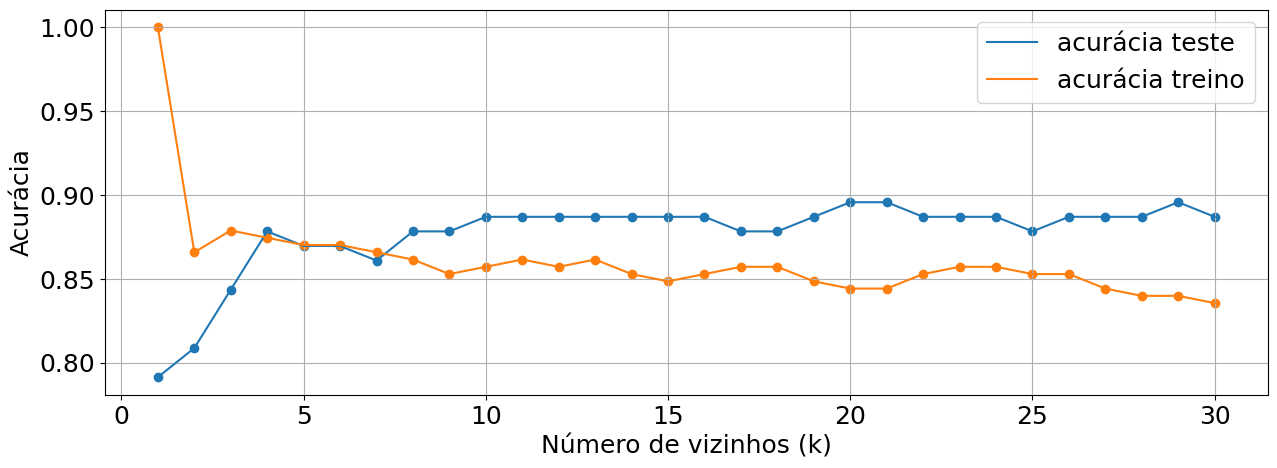

In [40]:
plt.figure(figsize=(15,5))

plt.plot(range(1,k_max+1), acu_teste, label='acurácia teste');
plt.plot(range(1,k_max+1), acu_treino, label='acurácia treino');

plt.scatter(range(1,k_max+1), acu_teste);
plt.scatter(range(1,k_max+1), acu_treino);

plt.xlabel('Número de vizinhos (k)')
plt.ylabel('Acurácia');
plt.grid()
plt.legend();

In [41]:
np.argmax(acu_teste)

np.int64(19)

In [42]:
acu_teste[np.argmax(acu_teste)]

0.8956521739130435

In [43]:
k_norm = int(np.argmax(acu_teste)) + 1
melhor_k2 = KNeighborsClassifier(k_norm)
melhor_k2.fit(X_scaled_treino, y_scaled_treino)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
curvas['normalizado'] = {'treino': acu_treino, 'teste': acu_teste, 'melhor_k': k_norm,
                         'pred_x': int(melhor_k2.predict(scaler.transform(x_novo))[0])}

melhor_k2.predict(scaler.transform(x_novo))

array([0])

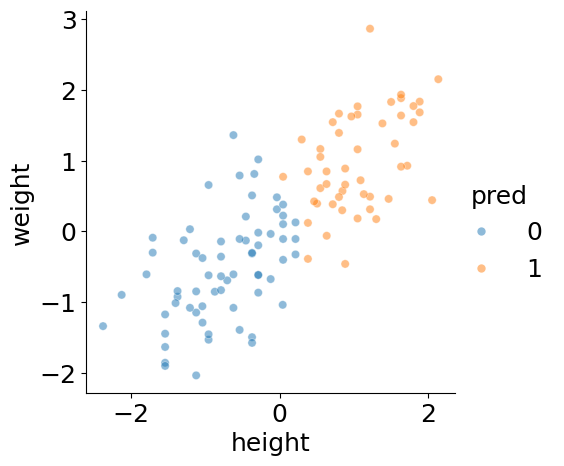

In [45]:
dados2 = pd.DataFrame(X_scaled_teste)
dados2.columns = ['height', 'weight']
dados2['pred'] = melhor_k2.predict(X_scaled_teste)
sns.relplot(data=dados2, x='height', y='weight', hue='pred', alpha=0.5)

Usando só a altura?

In [46]:
df2 = df[['height', 'male']]

In [47]:
# mesma semente => mesma partição dos experimentos anteriores
df_treino2, df_teste2 = train_test_split(df2, test_size=0.33, shuffle=True, random_state=SEED)
X_treino2 = df_treino2[['height']]
y_treino2 = df_treino2['male']
X_teste2 = df_teste2[['height']]
y_teste2 = df_teste2['male']

In [48]:
acu_teste = []
acu_treino = []

for i in range(1,k_max+1):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_treino2, y_treino2)

    y_pred_treino = model.predict(X_treino2)
    y_pred_teste = model.predict(X_teste2)

    acu_teste.append(accuracy_score(y_teste2, y_pred_teste))
    acu_treino.append(accuracy_score(y_treino2, y_pred_treino))

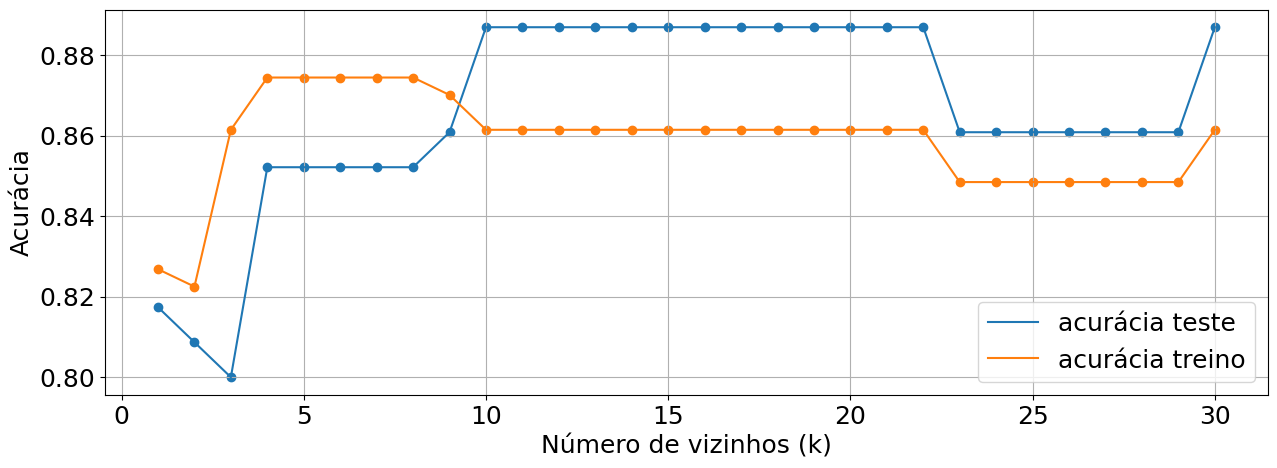

In [49]:
plt.figure(figsize=(15,5))

plt.plot(range(1,k_max+1), acu_teste, label='acurácia teste');
plt.plot(range(1,k_max+1), acu_treino, label='acurácia treino');

plt.scatter(range(1,k_max+1), acu_teste);
plt.scatter(range(1,k_max+1), acu_treino);

plt.xlabel('Número de vizinhos (k)')
plt.ylabel('Acurácia');
plt.grid()
plt.legend();

Melhor k usando só a altura

In [50]:
k_altura = int(np.argmax(acu_teste)) + 1
melhor_k3 = KNeighborsClassifier(k_altura)
melhor_k3.fit(X_treino2, y_treino2)

curvas['altura'] = {'treino': acu_treino, 'teste': acu_teste, 'melhor_k': k_altura,
                    'pred_x': int(melhor_k3.predict(x_novo[['height']])[0])}

k_altura, acu_teste[k_altura - 1]

(10, 0.8869565217391304)

## Comparando os três experimentos
Mesma partição treino/teste nos três, então as acurácias são diretamente comparáveis. `pred_X` é a classe prevista para o ponto X (0 = mulher, 1 = homem).

In [51]:
resumo = pd.DataFrame([
    {'experimento': nome,
     'melhor_k': c['melhor_k'],
     'acuracia_treino': c['treino'][c['melhor_k'] - 1],
     'acuracia_teste': c['teste'][c['melhor_k'] - 1],
     'pred_X': c['pred_x']}
    for nome, c in curvas.items()])
resumo

,experimento,melhor_k,acuracia_treino,acuracia_teste,pred_X
0,bruto,11,0.870130,0.895652,0
1,normalizado,20,0.844156,0.895652,0
2,altura,10,0.861472,0.886957,0


## Base de dados da animação
A animação (`knn_animacao.html`) não refaz o KNN por conta própria: ela desenha o que o `sklearn` calculou aqui. Para cada experimento e cada k guardamos as predições do teste, a matriz de confusão, os vizinhos do ponto X e a fronteira de decisão amostrada numa grade.

In [52]:
import base64, json, re
from datetime import datetime
import sklearn

# janela (cm x kg) onde a fronteira de decisão é amostrada, linha a linha, de baixo para cima
GRADE = dict(x0=118.0, x1=198.0, y0=22.0, y1=72.0, nx=160, ny=100)
gx = GRADE['x0'] + (np.arange(GRADE['nx']) + 0.5) * (GRADE['x1'] - GRADE['x0']) / GRADE['nx']
gy = GRADE['y0'] + (np.arange(GRADE['ny']) + 0.5) * (GRADE['y1'] - GRADE['y0']) / GRADE['ny']
grade_2d = np.array([(x, y) for y in gy for x in gx])
NX_1D = 320
grade_1d = (GRADE['x0'] + (np.arange(NX_1D) + 0.5) * (GRADE['x1'] - GRADE['x0']) / NX_1D).reshape(-1, 1)

def empacota(bits):
    # 0/1 por célula -> 1 bit por célula, em base64
    return base64.b64encode(np.packbits(np.asarray(bits, dtype=np.uint8)).tobytes()).decode('ascii')

def descreve(nome, Xtr, Xte, x_ponto, X_grade, nx, ny, guardar_vizinhos):
    Xtr, Xte, x_ponto, X_grade = (np.asarray(a, dtype=float) for a in (Xtr, Xte, x_ponto, X_grade))
    ytr, yte = y_treino.to_numpy(), y_teste.to_numpy()
    ids_treino = df_treino.index.to_numpy()
    exp = {c: [] for c in ('acu_treino', 'acu_teste', 'pred_teste', 'matriz',
                           'pred_x', 'viz_x', 'raio_x', 'grade')}
    for k in range(1, k_max + 1):
        m = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
        pred = m.predict(Xte)
        dist, viz = m.kneighbors(x_ponto)
        exp['acu_treino'].append(accuracy_score(ytr, m.predict(Xtr)))
        exp['acu_teste'].append(accuracy_score(yte, pred))
        exp['pred_teste'].append(''.join(map(str, pred)))
        exp['matriz'].append(confusion_matrix(yte, pred).tolist())
        exp['pred_x'].append(int(m.predict(x_ponto)[0]))
        exp['viz_x'].append(ids_treino[viz[0]].tolist())
        exp['raio_x'].append(round(float(dist[0, -1]), 5))
        exp['grade'].append(empacota(m.predict(X_grade)))

    # a animação tem de terminar no resultado do notebook: confere com as curvas das células acima
    assert np.allclose(exp['acu_teste'], curvas[nome]['teste']), nome
    assert np.allclose(exp['acu_treino'], curvas[nome]['treino']), nome
    assert exp['pred_x'][curvas[nome]['melhor_k'] - 1] == curvas[nome]['pred_x'], nome

    exp.update(melhor_k=curvas[nome]['melhor_k'], nx=nx, ny=ny)
    if guardar_vizinhos:
        # vizinhos de cada ponto de teste (para inspecionar a decisão ponto a ponto)
        viz = KNeighborsClassifier(n_neighbors=k_max).fit(Xtr, ytr).kneighbors(Xte, return_distance=False)
        exp['viz_teste'] = ids_treino[viz].tolist()
        # os k primeiros vizinhos reproduzem o voto do modelo de k vizinhos? (empates de distância podem quebrar isso)
        exp['prefixo_ok'] = all(
            ''.join(map(str, (ytr[viz[:, :k]].sum(axis=1) * 2 > k).astype(int))) == exp['pred_teste'][k - 1]
            for k in range(1, k_max + 1))
    return exp

x_altura = x_novo[['height']]
experimentos = {
    'bruto': descreve('bruto', X_treino, X_teste, x_novo, grade_2d, GRADE['nx'], GRADE['ny'], True),
    'normalizado': descreve('normalizado', X_scaled_treino, X_scaled_teste, scaler.transform(x_novo),
                            scaler.transform(pd.DataFrame(grade_2d, columns=['height', 'weight'])),
                            GRADE['nx'], GRADE['ny'], True),
    'altura': descreve('altura', X_treino2, X_teste2, x_altura, grade_1d, NX_1D, 1, False),
}

# o quadro final da animação é, ponto a ponto, o que as células acima previram (dados['pred'] e dados2['pred'])
assert experimentos['bruto']['pred_teste'][k_bruto - 1] == ''.join(map(str, dados['pred']))
assert experimentos['normalizado']['pred_teste'][k_norm - 1] == ''.join(map(str, dados2['pred']))

{nome: (e['melhor_k'], round(e['acu_teste'][e['melhor_k'] - 1], 4), e.get('prefixo_ok')) for nome, e in experimentos.items()}

{'bruto': (11, 0.8957, True),
 'normalizado': (20, 0.8957, True),
 'altura': (10, 0.887, None)}

In [53]:
# por linha do CSV: 'f' = filtrada (age <= 18), 'r' = treino, 't' = teste
conjunto = pd.Series('f', index=df_completo.index)
conjunto[df_treino.index] = 'r'
conjunto[df_teste.index] = 't'

dados_animacao = {
    'meta': {'semente': SEED, 'test_size': 0.33, 'k_max': k_max,
             'sklearn': sklearn.__version__, 'gerado_em': datetime.now().isoformat(timespec='seconds')},
    'linhas': {'altura': df_completo['height'].round(3).tolist(),
               'peso': df_completo['weight'].round(3).tolist(),
               'idade': df_completo['age'].round(1).tolist(),
               'homem': df_completo['male'].astype(int).tolist()},
    'conjunto': ''.join(conjunto),
    'teste': df_teste.index.tolist(),          # ordem das predições em pred_teste
    'ponto_x': list(ponto_x),
    'escala': {'media': scaler.mean_.tolist(), 'desvio': scaler.scale_.tolist()},
    'grade': GRADE,
    'experimentos': experimentos,
    'resumo': resumo.to_dict('records'),
}

texto = json.dumps(dados_animacao, separators=(',', ':')).replace('</', '<\\/')
Path('knn_animacao_dados.json').write_text(texto, encoding='utf-8')

# injeta a base na página, que assim continua sendo um arquivo único e abre direto do disco
pagina = Path('knn_animacao.html')
if pagina.exists():
    bloco = re.compile(r'(<script id="knn-dados" type="application/json">)(.*?)(</script>)', re.S)
    html, trocas = bloco.subn(lambda m: m.group(1) + texto + m.group(3), pagina.read_text(encoding='utf-8'))
    assert trocas == 1, 'bloco knn-dados não encontrado em knn_animacao.html'
    pagina.write_text(html, encoding='utf-8')

f'{len(texto) / 1024:.0f} KB exportados' + (' e injetados em knn_animacao.html' if pagina.exists() else '')

'219 KB exportados e injetados em knn_animacao.html'